# **Final Notebook: Handcrafted Window Features**

In [1]:
#imports
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if os.getcwd().endswith("notebooks_final"):
    os.chdir("../")
from src_final.features.local_feature_extractor import WindowFeatureExtractor
from src_final.features.aggregation import aggregate_window_features
from src_final.models.analysis import leakage_free_residual_analysis
from src_final.models.baseline_loso import evaluate_loso_model

In [2]:
processed_path = "data/processed/landmark_dataframes/"
paths = [os.path.join(processed_path, f) for f in os.listdir(processed_path) if f.endswith("30fps_processed.pkl")]

df_dict = {}
cols_to_keep = ['frame', 'hand_label', 'cx_smooth', 'cy_smooth']

# load df with where first column in csv serves as index
df_vid_name_map = pd.read_csv("data/scores/vid_name_map.csv", index_col=0)

with tqdm(total=len(paths), desc="Loading processed data") as pbar:
    for path in paths:
        vid = os.path.basename(path).replace("_30fps_processed.pkl", "")
        vid = vid.replace("hand_tracking_", "")
        participant_id = df_vid_name_map.loc[vid]['Participant Number']
        if int(participant_id) == 8:
            continue
        df_dict[(vid, int(participant_id))] = pd.read_pickle(path)#[cols_to_keep]
        pbar.update(1)

df_dict = dict(sorted(df_dict.items()))

df_scores = pd.read_csv("data/scores/merged_scores.csv")[['Vid_Name', 'QRS_Overal']]
grs_scores = df_scores.set_index('Vid_Name')['QRS_Overal'].to_dict()

Loading processed data:  97%|█████████▋| 83/86 [00:04<00:00, 17.83it/s]


In [3]:
# 1. Initialize and Prepare Data
extractor = WindowFeatureExtractor(hand="Right", window_sec=1.5, step_sec=0.5, log_transform=True, include_bimanual=False, exclude_idle=False)
df_window_features = extractor.extract_features(df_dict)

Extracting Right Features: 100%|██████████| 83/83 [01:51<00:00,  1.34s/it]


In [ ]:
extractor = WindowFeatureExtractor(hand="Left", window_sec=1.5, step_sec=0.5, log_transform=True, include_bimanual=True, exclude_idle=False)
df_window_features_left = extractor.extract_features(df_dict)

Extracting Left Features:  27%|██▋       | 22/83 [00:26<01:14,  1.22s/it]


KeyboardInterrupt: 

In [4]:
feature_cols = [col for col in df_window_features.columns if col not in ['video_id', 'window_start_frame']]

In [5]:
df_window_features[feature_cols].corr()

,total_path,is_idle,path_ratio,spatial_spread,zvr,sparc,hf_ratio,speed_peaks,acc_rms,palm_area_cv
total_path,1.000000,-0.180674,0.120352,0.813685,-0.661800,0.186177,-0.110900,-0.289625,0.805250,0.492887
is_idle,-0.180674,1.000000,-0.052199,-0.349084,0.368739,-0.135523,0.119925,0.202871,-0.374877,-0.180039
path_ratio,0.120352,-0.052199,1.000000,-0.175466,-0.241130,-0.262501,0.495731,0.417123,0.338199,0.298371
spatial_spread,0.813685,-0.349084,-0.175466,1.000000,-0.778286,0.375939,-0.432492,-0.560688,0.760092,0.438588
zvr,-0.661800,0.368739,-0.241130,-0.778286,1.000000,-0.108767,0.042061,0.202747,-0.853332,-0.567371
sparc,0.186177,-0.135523,-0.262501,0.375939,-0.108767,1.000000,-0.569567,-0.487073,0.126966,0.022289
hf_ratio,-0.110900,0.119925,0.495731,-0.432492,0.042061,-0.569567,1.000000,0.679343,0.028222,0.087512
speed_peaks,-0.289625,0.202871,0.417123,-0.560688,0.202747,-0.487073,0.679343,1.000000,-0.167885,-0.010745
acc_rms,0.805250,-0.374877,0.338199,0.760092,-0.853332,0.126966,0.028222,-0.167885,1.000000,0.628974
palm_area_cv,0.492887,-0.180039,0.298371,0.438588,-0.567371,0.022289,0.087512,-0.010745,0.628974,1.000000


In [6]:
#df_window_features_right = df_window_features
#df_window_features = df_window_features_right
df_window_features = df_window_features_left

NameError: name 'df_window_features_left' is not defined

In [8]:
df_bimanual = df_window_features[df_window_features['bimanual_dist_mean'].notna()]
print(len(df_bimanual), "bimanual windows out of", len(df_window_features))

KeyError: 'bimanual_dist_mean'

In [12]:
import numpy as np

def aggregate_window_features(df_windows, p=90, active_with_idle=True):
    """
    Aggregates window-level features into video-level descriptors, 
    separating 'Decision Time' (Idle) from 'Execution Quality' (Active).
    """
    
    # --- 1. Pre-Aggregation Feature Engineering ---
    # Convert raw Bimanual Ratio (0-1) into "Hand Bias" (0.0=Balanced, 0.5=One-handed)
    # We do this here because the variance of the raw ratio is ambiguous.
    if 'bimanual_ratio' in df_windows.columns:
        df_windows['bimanual_imbalance'] = (df_windows['bimanual_ratio'] - 0.5).abs()

    # --- 2. Global Economy (The "Hesitation" Signal) ---
    # We use the whole dataframe (Idle + Active) for this
    df_economy = df_windows.groupby('video_id')['is_idle'].agg(
        idle_prop='mean'      # % of time spent waiting
    )

    # --- 3. Active Kinematics (The "Skill" Signal) ---
    # Filter for active windows only
    if not active_with_idle:
        df_active = df_windows[df_windows['is_idle'] == 0].copy()
    else:
        df_active = df_windows.copy()
    
    
    # Define aggregation strategies based on feature type
    # A. Magnitude Features (Where the 'Average' matters)
    #    Velocity, Spacing, Ang Velocity
    possible_feats = [
        'zvr', 'vel_p90', 'spatial_spread', 
        'acc_rms', 'hf_ratio', 'path_ratio', 
        'sparc', 'palm_area_cv', 'speed_peaks'
    ]
    
    # Filter lists to ensure columns actually exist
    feats = [c for c in possible_feats if c in df_active.columns]

    # helper for clean names
    def make_percentile_funcs(p):
        def high(x):
            return np.percentile(x, p)
        def low(x):
            return np.percentile(x, 100-p)

        high.__name__ = f"p{p}"
        low.__name__  = f"p{100-p}"

        return high, low


    p_high, p_low = make_percentile_funcs(p)

    
    aggs = {}
    
    for f in feats:
        aggs[f] = ['median', 'std', p_high, p_low]

    df_kinematics = df_active.groupby('video_id').agg(aggs)
    
    # --- 4. Flatten MultiIndex Columns Cleanly ---
    # Result: vel_mean_median, jerk_max, etc.
    df_kinematics.columns = [f"{c[0]}_{c[1]}" for c in df_kinematics.columns]

    # --- 5. Merge ---
    df_final = df_economy.join(df_kinematics, how='left')

    bimanual_feats = ['bimanual_dist_mean', 'bimanual_dist_std', 'bimanual_sync', 'bimanual_imbalance']

    if all(f in df_windows.columns for f in bimanual_feats):
        df_bimanual = df_windows[df_windows['bimanual_dist_mean'].notna() &
                                 df_windows['bimanual_dist_std'].notna() & 
                                 df_windows['bimanual_sync'].notna() & 
                                 df_windows['bimanual_imbalance'].notna()][['video_id']+bimanual_feats]
        
        aggs = {}
    
        for f in bimanual_feats:
            aggs[f] = ['median', 'std', p_high, p_low]

        df_bimanual_agg = df_bimanual.groupby('video_id').agg(aggs)
        df_bimanual_agg.columns = [f"{c[0]}_{c[1]}" for c in df_bimanual_agg.columns]
        df_final = df_final.join(df_bimanual_agg, how='left')
    
    return df_final.reset_index()

In [13]:
# Usage
df_window_features['is_idle'] = (df_window_features['total_path'] < 45).astype(int)
df_agg = aggregate_window_features(df_window_features, p=75, active_with_idle=False)

In [14]:
df_agg2 = aggregate_window_features(df_window_features, p=90, active_with_idle=False)
cols = [col for col in df_agg2.columns if 'p90' in col or 'p10' in col]
# merge distinct columns of df_agg and df_agg2
df_agg = df_agg.merge(df_agg2[cols + ['video_id']], on=['video_id'])

In [15]:
from scipy.stats import pearsonr, spearmanr

candidate_features = [col for col in df_agg.columns if col not in ['video_id']]
scores = list(grs_scores.values())

#shuffle scores
import random
#random.seed(42)
#random.shuffle(scores)

feature_df = df_agg[candidate_features]
# compute correlation with scores both pearson and spearman
from scipy.stats import pearsonr, spearmanr
features = list(feature_df.columns)
pearson_corrs = []
spearman_corrs = []
for i in range(feature_df.shape[1]):
    pearson_corr, _ = pearsonr(feature_df.iloc[:, i], scores)
    spearman_corr, _ = spearmanr(feature_df.iloc[:, i], scores)
    pearson_corrs.append(pearson_corr)
    spearman_corrs.append(spearman_corr)

print("Top 15 features by Pearson correlation:")
top_pearson_indices = np.argsort(np.abs(pearson_corrs))[::-1][:40]
for idx in top_pearson_indices:
    print(f"{features[idx]}:        Pearson r = {pearson_corrs[idx]:.4f}, Spearman rho = {spearman_corrs[idx]:.4f}")

Top 15 features by Pearson correlation:
path_ratio_std:        Pearson r = 0.4535, Spearman rho = 0.4621
speed_peaks_std:        Pearson r = 0.4470, Spearman rho = 0.4683
path_ratio_p75:        Pearson r = 0.4446, Spearman rho = 0.4592
path_ratio_p90:        Pearson r = 0.4365, Spearman rho = 0.4460
hf_ratio_p90:        Pearson r = 0.4157, Spearman rho = 0.4465
palm_area_cv_median:        Pearson r = 0.4130, Spearman rho = 0.4166
spatial_spread_median:        Pearson r = -0.3802, Spearman rho = -0.3785
speed_peaks_p75:        Pearson r = 0.3796, Spearman rho = 0.3630
spatial_spread_p75:        Pearson r = -0.3712, Spearman rho = -0.3375
palm_area_cv_p75:        Pearson r = 0.3703, Spearman rho = 0.3678
hf_ratio_p75:        Pearson r = 0.3702, Spearman rho = 0.3854
hf_ratio_std:        Pearson r = 0.3691, Spearman rho = 0.4158
path_ratio_median:        Pearson r = 0.3688, Spearman rho = 0.3558
speed_peaks_p90:        Pearson r = 0.3685, Spearman rho = 0.3397
palm_area_cv_p25:        Pea

In [16]:
# load top feature df and combine with aggregated window features
df_top_features = pd.read_csv("data/metrics/top_features_df.csv")
df_pc1_features = pd.read_csv("data/metrics/global_pc1_features.csv")

df_combined = pd.merge(df_pc1_features, df_agg, left_index=True, right_index=True)

In [52]:
# one hot encode Case_Number
#df_case_onehot = pd.get_dummies(df_combined['Case_Number'], prefix='Case').astype(int)

#if not any('Case_1' in col for col in df_combined.columns):
#    df_combined = pd.concat([df_combined, df_case_onehot], axis=1)

In [17]:
top_features = [
    'angular_dir_switches_Right',
    'nmu_peaks_Right',
    'total_duration_Left',
    #'total_duration_Right',
    'total_path_Right',
    'angular_dir_switches_Left',
    'nmu_peaks_Left',
    'ldlj_smoothness_Left',
    'total_path_Left',
    'total_angular_path_Right',
    'ldlj_smoothness_Right',
    'total_angular_path_Left'
    ]

top_features_right = [feat for feat in top_features if 'Right' in feat]

#top_features = ['angular_dir_switches_Right']

candidate_features = [col for col in df_combined.columns if col not in ['Participant Number', 'Case_Number', 'GRS_Total', 'QRS_Overal', 'video_id']+top_features]

candidate_features = [col for col in candidate_features if 'bimanual' not in col]

#candidate_features.remove('velocity_ratio')
df_res_leakage_free = leakage_free_residual_analysis(df_combined, top_features_right, base_features=['velocity_corr'], candidate_features=candidate_features, top_n=1)
df_res_leakage_free

# - Just observed that spatial spread p80 (idle thresh < 15px and, log transform, and 1.5 sec window) is very strong.

Analyzing Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Analyzing Folds: 100%|██████████| 28/28 [00:05<00:00,  5.02it/s]


,Feature,Partial_R2_mean,Partial_R2_std,Partial_R2_min,Resid_Corr_mean,Selection_Stability
34,spatial_spread_p75,0.166887,1.328815e-02,1.387558e-01,-0.392737,1.0
15,palm_area_cv_p25,0.098034,9.745498e-03,7.663103e-02,0.304495,0.0
31,spatial_spread_median,0.090909,1.410537e-02,6.845421e-02,-0.279159,0.0
35,spatial_spread_p90,0.082044,1.293541e-02,5.755763e-02,-0.277487,0.0
14,palm_area_cv_p10,0.077975,1.227701e-02,5.915510e-02,0.274127,0.0
39,speed_peaks_p25,0.063614,1.149828e-02,4.736232e-02,0.248227,0.0
13,palm_area_cv_median,0.060577,9.185892e-03,4.218531e-02,0.229620,0.0
19,path_ratio_median,0.050296,7.409073e-03,3.460051e-02,0.212284,0.0
22,path_ratio_p75,0.049765,9.375381e-03,2.958654e-02,0.199940,0.0
5,acc_rms_std,0.049547,1.320191e-02,2.036147e-02,-0.208415,0.0


In [17]:
# top_features intercorrelation
top_candidates = df_res_leakage_free['Feature'].values[:5].tolist()
df_combined[top_candidates+['velocity_corr']].corr()

,spatial_spread_p75,palm_area_cv_p25,spatial_spread_median,spatial_spread_p90,palm_area_cv_p10,velocity_corr
spatial_spread_p75,1.000000,-0.211389,0.548296,0.699870,-0.223922,-0.220238
palm_area_cv_p25,-0.211389,1.000000,0.160465,-0.163979,0.909932,-0.085882
spatial_spread_median,0.548296,0.160465,1.000000,0.200589,0.091054,-0.255790
spatial_spread_p90,0.699870,-0.163979,0.200589,1.000000,-0.191165,-0.184489
palm_area_cv_p10,-0.223922,0.909932,0.091054,-0.191165,1.000000,-0.088967
velocity_corr,-0.220238,-0.085882,-0.255790,-0.184489,-0.088967,1.000000


In [18]:
# Do the distributions of the top features seem reasonable?
df_agg[top_candidates].describe()

,spatial_spread_p75,palm_area_cv_p25,spatial_spread_median,spatial_spread_p90,palm_area_cv_p10
count,83.000000,83.000000,83.000000,83.000000,83.000000
mean,3.600032,0.126371,3.042039,4.317719,0.058528
std,0.165195,0.053650,0.146825,0.190938,0.022863
min,3.164537,0.047738,2.581384,3.746899,0.021865
25%,3.487571,0.079183,2.946653,4.179976,0.039359
50%,3.610700,0.112374,3.043024,4.320175,0.053474
75%,3.692391,0.156286,3.134169,4.463124,0.075342
max,4.024497,0.297257,3.475790,4.694561,0.116673


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 45.36it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7428 | MAE: 5.2724 | MAE STD: 3.4989 | R2: 0.5379 | Adj R2: 0.5142

Feature Weights:
              Feature  Average_Weight  Std_Weight
0                bias       49.938586    0.302804
1                 PC1       -2.159316    0.060063
2       velocity_corr       -2.036550    0.181915
3  spatial_spread_p75       -2.450467    0.136251

--- Per-Fold Performance Summary ---
    Train_MAE  Test_MAE  Test_Corr
1    4.728397  7.050641  -0.160135
2    4.937188  2.182555   0.978313
3    4.786082  8.250660   0.998366
4    4.767118  6.164139   0.438174
5    4.753674  6.744653   0.233679
6    4.864709  5.618368   0.944822
7    4.663058  8.933298  -0.837017
9    4.895174  4.057280  -0.999973
10   4.880268  5.081315   0.515360
11   4.904454  3.499908  -0.462972
12   4.879329  4.272524  -0.403181
13   4.930382  3.201414   0.491943
14   4.892711  4.519720   0.984028
15   4.833712  7.523290   0.728095
16   4.739244  7.373456   0.322200
17   4.969310  1.6147

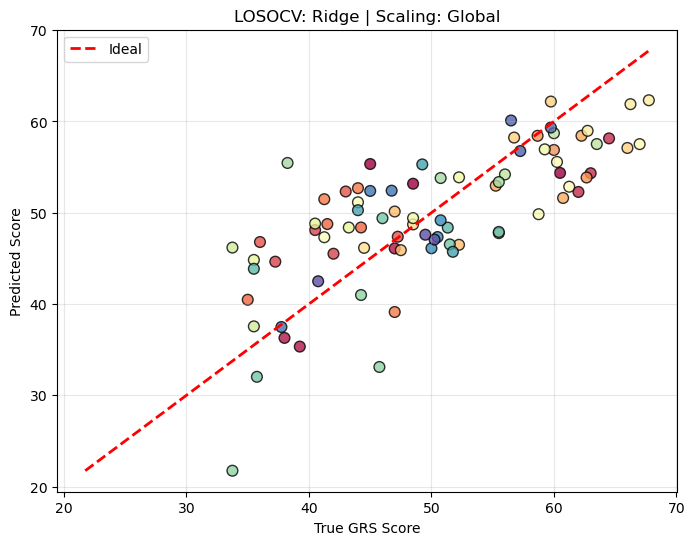

In [19]:
_, _, _ = evaluate_loso_model(df_combined, top_features, pca_components=[0], extra_features=['velocity_corr', 'spatial_spread_p75'], print_fold_metrics=True)

# Test Shuffled Residuals

In [38]:
all_shuffled_r2 = []
all_shuffled_p80_spread = []
all_shuffled_parea_cv = []
for seed in range(300):
    df_res = leakage_free_residual_analysis(df_combined, top_features, candidate_features, base_features=['velocity_corr'], top_n=2, perform_shuffle=True, seed=seed)
    top_3_r2 = df_res['Shuffled_R2_mean'].values[:3]
    p80_spread_r2 = df_res[df_res['Feature']=='spatial_spread_p90']['Shuffled_R2_mean'].values[0]
    parea_cv_r2 = df_res[df_res['Feature']=='palm_area_cv_median']['Shuffled_R2_mean'].values[0]
    all_shuffled_p80_spread.append(p80_spread_r2)
    all_shuffled_parea_cv.append(parea_cv_r2)
    print(f"Seed {seed}: Top 3 R2: {top_3_r2}")
    for r2 in top_3_r2:
        all_shuffled_r2.append(r2)

Analyzing Folds: 100%|██████████| 28/28 [00:03<00:00,  7.38it/s]


Seed 0: Top 3 R2: [0.06826293 0.05270125 0.04885616]


Analyzing Folds:  32%|███▏      | 9/28 [00:01<00:02,  6.64it/s]


KeyboardInterrupt: 

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- DATA INPUT ---
# Your top real feature R2
real_top_r2 = 0.13810437704789127

# Replace this with your actual list of 50 'Max' Shuffled R2 values 
# (The highest R2 observed in each of the 50 shuffle runs)

shuffled_max_r2s = all_shuffled_r2[::3] # your 50 max values

def evaluate_significance(real_val, null_distribution):
    null_distribution = np.array(null_distribution)
    
    # Empirical p-value: what fraction of the null is >= our real signal?
    p_value = np.mean(null_distribution >= real_val)
    
    # Z-score: how many standard deviations is the real signal from the null mean?
    z_score = (real_val - np.mean(null_distribution)) / np.std(null_distribution)
    
    return p_value, z_score

p_val, z_score = evaluate_significance(real_top_r2, shuffled_max_r2s)

print(f"Empirical p-value: {p_val:.3f}")
print(f"Z-score vs Null: {z_score:.2f}")

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.hist(shuffled_max_r2s, bins=25, alpha=0.6, label='Null Distribution (Max Shuffled R2)')
plt.axvline(real_top_r2, color='red', linestyle='--', linewidth=2, label=f'Real Feature (R2={real_top_r2})')
plt.title("Is the Signal Better Than Random Noise?")
plt.xlabel("Partial R2")
plt.ylabel("Frequency")
plt.legend()
plt.show()

NameError: name 'all_shuffled_r2' is not defined

### Verdict

- The Conservative Choice is to only accept spatial spread p80 as a valid additional feature (reason statistical significance)

- A valid second choice would probably be within fold direct selection of top 2 features, slighly better performance, but likely a bit over optimistic/overfitted


## **MLP Model**


In [88]:
from src_final.models.mlp_regressor import PyTorchMLPEnsemble
from src_final.models.baseline_loso import evaluate_loso_mlp_ensemble

_, _, _ = evaluate_loso_mlp_ensemble(
    model_class=PyTorchMLPEnsemble,
    df=df_combined,
    primary_features=top_features,
    extra_features=['velocity_corr']+['spatial_spread_p90'],
    model_params={'hidden_dim': 12, 'n_hidden': 1, 'n_models': 5, 'dropout': 0.1, 'batch_size': 16},
    pca_components=[0],
    print_fold_metrics=True
)

LOSOCV Ensemble Folds:   0%|          | 0/28 [00:00<?, ?it/s]
KeyboardInterrupt



In [27]:
candidate_features

['velocity_corr',
 'vel_mean_median',
 'vel_mean_std',
 'vel_mean_p80',
 'vel_mean_p20',
 'vel_p90_median',
 'vel_p90_std',
 'vel_p90_p80',
 'vel_p90_p20',
 'spatial_spread_median',
 'spatial_spread_std',
 'spatial_spread_p80',
 'spatial_spread_p20',
 'ang_vel_mean_median',
 'ang_vel_mean_std',
 'ang_vel_mean_p80',
 'ang_vel_mean_p20',
 'curvature_median',
 'curvature_std',
 'curvature_p80',
 'curvature_p20',
 'path_ratio_median',
 'path_ratio_std',
 'path_ratio_p80',
 'path_ratio_p20',
 'palm_area_cv_median',
 'palm_area_cv_std',
 'palm_area_cv_p80',
 'palm_area_cv_p20']

In [27]:
from src_final.models.mlp_regressor import PyTorchMLPEnsemble
from src_final.models.baseline_loso import evaluate_loso_mlp_ensemble, run_nested_loso

df_nested_results = run_nested_loso(
    df=df_combined,
    primary_features=top_features_right,
    candidate_features=candidate_features,
    extra_features=['velocity_corr'],
    model_type='ridge',
    model_params={'hidden_dim': 16, 'n_hidden': 1, 'n_models': 5, 'dropout': 0.15, 'batch_size': 16},
    top_n=6,
    print_fold_metrics=True,
    corr_threshold=0.8,
    pr2_threshold=0.05
)

Surgeon 1 | Train MAE: 4.2914 | Test MAE: 4.5128 | Selected Features: ['spatial_spread_p75', 'spatial_spread_p90', 'palm_area_cv_p25', 'spatial_spread_median'] | Selected PR2s: [np.float64(0.1572), np.float64(0.0899), np.float64(0.0766), np.float64(0.0721)]
Surgeon 2 | Train MAE: 4.2245 | Test MAE: 5.1246 | Selected Features: ['spatial_spread_p75', 'palm_area_cv_p25', 'spatial_spread_median', 'spatial_spread_p90', 'speed_peaks_p25', 'path_ratio_p75'] | Selected PR2s: [np.float64(0.1584), np.float64(0.1083), np.float64(0.0905), np.float64(0.075), np.float64(0.063), np.float64(0.0501)]
Surgeon 3 | Train MAE: 4.1521 | Test MAE: 9.5976 | Selected Features: ['spatial_spread_p75', 'spatial_spread_median', 'palm_area_cv_p25', 'acc_rms_std', 'spatial_spread_p90', 'path_ratio_median'] | Selected PR2s: [np.float64(0.1781), np.float64(0.1172), np.float64(0.1147), np.float64(0.0772), np.float64(0.0689), np.float64(0.0575)]
Surgeon 4 | Train MAE: 4.3192 | Test MAE: 4.2403 | Selected Features: ['spa

ridge with p80 no idle and vel_corr already as a feature
=== Nested LOSO Summary (ridge) ===
MAE: 4.7791 +/- 3.3512
Train MAE: 4.2873
Spearman R: 0.7996

Feature Selection Stability:
spatial_spread_p80       1.0
palm_area_cv_p20         1.0
spatial_spread_median    1.0


without vel corr as feature:
=== Nested LOSO Summary (ridge) ===
MAE: 4.7423 +/- 3.5384
Train MAE: 4.3503
Spearman R: 0.7804

Feature Selection Stability:
velocity_corr         1.0
palm_area_cv_p20      1.0
spatial_spread_p80    1.0

with MLP {'hidden_dim': 24, 'n_hidden': 2, 'n_models': 5, 'dropout': 0.15, 'batch_size': 16},
=== Nested LOSO Summary (mlp) ===
MAE: 4.6731 +/- 3.5582
Train MAE: 3.4889
Spearman R: 0.7798

Feature Selection Stability:
spatial_spread_p80       1.0
palm_area_cv_p20         1.0
spatial_spread_median    1.0
Name: count, dtype: float64

=== Nested LOSO Summary (mlp) ===
MAE: 4.7600 +/- 3.4687
Train MAE: 3.8513
Spearman R: 0.7787

{'hidden_dim': 16, 'n_hidden': 1, 'n_models': 5, 'dropout': 0.15, 'batch_size': 16},
Feature Selection Stability:
spatial_spread_p80       1.0
palm_area_cv_p20         1.0
spatial_spread_median    1.0
Name: count, dtype: float64

Make a plot of perfromance metrics over top_n selected features
=> this proves local signal is there but here we would need ot peek at the test data to pick the top_n parameter...

LOSOCV Folds:   0%|          | 0/28 [00:00<?, ?it/s]

/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.029e-01, tolerance: 5.093e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.463e-01, tolerance: 5.093e-01
  model = cd_fast.enet_coordinate_descent_gram(
LOSOCV Folds:  11%|█         | 3/28 [00:00<00:05,  4.82it/s]/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not con


=== LOSOCV Results (Global Scaling) ===
R: 0.7473 | MAE: 4.9725 | MAE STD: 3.6580 | R2: 0.5602 | Adj R2: 0.3195

Feature Weights:
                  Feature  Average_Weight  Std_Weight
0                    bias       49.938586    0.302804
1                     PC1       -2.756005    0.131387
2           velocity_corr       -1.746163    0.214804
3    total_duration_Right        0.000000    0.000000
4               idle_prop       -0.072889    0.142618
5              zvr_median        0.000000    0.000000
6                 zvr_std        0.000000    0.000000
7                 zvr_p75        0.000000    0.000000
8                 zvr_p25        0.033437    0.160864
9          vel_p90_median        0.000000    0.000000
10            vel_p90_std        0.262446    0.326388
11            vel_p90_p75       -0.044791    0.232740
12            vel_p90_p25        0.000000    0.000000
13  spatial_spread_median       -1.670295    0.282933
14     spatial_spread_std       -0.000899    0.004672
15   

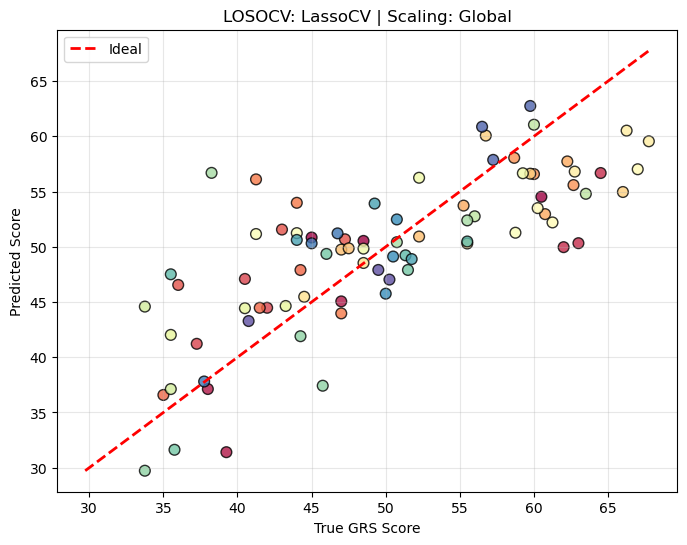

In [62]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

_, _, _ = evaluate_loso_model(df_combined, top_features_right, model_class=LassoCV, model_params={'alphas': np.logspace(-2, 2, 40)},extra_features=candidate_features, print_fold_metrics=True, pca_components=[0])

## **BoW**

**Need to scale features before k-means clustering**

- First do it with a little data leakage
- But for the final results need to do this within each fold!



note this could be optimized by using more adequate clustering (for heavy tailed distributions do if I have time and what to write about this in detail in my thesis)

Adequate Clustering for Power-Law Kinematics
Standard K-means is often poor for power-law data because squared Euclidean distances are overly sensitive to the extreme values in features like dim_jerk or vel_p90. 

3. Creating "BoW-like" Kinematic Embeddings
If you want embeddings that function like BoW but handle your specific feature set:
Normalization is Mandatory: Use a Robust Scaler (based on medians and quartiles) rather than a Standard Scaler to prevent power-law outliers from squashing your other data.
Log-Transform: For features like dim_jerk and palm_area_cv, applying a log transformation can pull the long tail in, making them more suitable for clustering.
Fisher Vectors: Instead of a simple BoW histogram, use Fisher Vectors to encode the first and second-order statistics (means and variances) of your kinematic clusters. This provides a much richer "embedding" than simple frequency counts. 

In [ ]:
# 1. Initialize and Prepare Data
extractor = WindowFeatureExtractor(hand="Right", window_sec=1.5, step_sec=0.5, log_transform=False, include_bimanual=False)
df_window_features = extractor.extract_features(df_dict)

Extracting Right Features: 100%|██████████| 83/83 [01:15<00:00,  1.10it/s]


In [10]:
from sklearn.preprocessing import RobustScaler, StandardScaler, QuantileTransformer, PowerTransformer
import numpy as np

def prepare_clustering_data(df_windows, feature_cols, method='log', clip=5.0):
    """
    Prepares kinematic data for K-Means clustering.
    
    Methods:
        'log': Original np.log1p approach.
        'sqrt': Square root transform (medium-strength tail compression).
        'quantile': Forces a uniform or normal distribution (removes skew entirely).
        'yeo-johnson': Parametric power transform to minimize skewness.
    """
    X = df_windows[feature_cols].copy()
    
    # Identify skewed targets
    skew_targets = [c for c in feature_cols if any(x == c for x in ['total_path', 'path_ratio', 'spatial_spread', 'zvr', 'sparc', 'vel_p90', 'palm_area_cv'])]
    
    # 1. Apply Primary Transform
    if method == 'log':
        for col in skew_targets:
            X[col] = np.log1p(X[col])
    elif method == 'sqrt':
        for col in skew_targets:
            X[col] = np.sqrt(np.abs(X[col]))
    elif method == 'quantile':
        # output_distribution='normal' makes it easier for K-means to find spherical blobs
        qt = QuantileTransformer(output_distribution='normal', n_quantiles=100, random_state=42)
        X[skew_targets] = qt.fit_transform(X[skew_targets])
    elif method == 'yeo-johnson':
        pt = PowerTransformer(method='yeo-johnson')
        X[skew_targets] = pt.fit_transform(X[skew_targets])

    # 2. Scaling
    # Using RobustScaler followed by StandardScaler is the "gold standard" for K-means
    # as it centers the data while remaining resistant to extreme window artifacts.
    #scaler = StandardScaler()
    scaler = RobustScaler()  # Uncomment this line to use RobustScaler instead of StandardScaler
    X_scaled = scaler.fit_transform(X)
    
    # 3. Clipping
    # A clip of 10.0 is very wide for a Z-scored distribution (10 standard deviations).
    # Standard practice is usually 3.0 or 5.0 to ensure outliers don't pull centroids.
    X_scaled = np.clip(X_scaled, -clip, clip)
    
    return X_scaled, scaler


In [11]:
clip = 5
with_idle = False

if not with_idle:
    df = df_window_features[df_window_features['total_path'] >= 45].copy()
else:
    df = df_window_features.copy()

In [7]:
#hist of each feature
import matplotlib.pyplot as plt

for col in feature_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=50, alpha=0.7)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

NameError: name 'feature_cols' is not defined

In [12]:
clustering_features

NameError: name 'clustering_features' is not defined

In [14]:
feature_cols = [col for col in df_window_features.columns if col not in ['video_id', 'window_start_frame', 'is_idle']]

# flip sign before log transform
df['sparc'] = -df['sparc']

# Workflow
clustering_features = [col for col in df_window_features.columns if col in feature_cols]
clustering_features = ['total_path',
 'path_ratio',
 'spatial_spread',
 'sparc',
 'palm_area_cv',]
X_for_km, scaler = prepare_clustering_data(df, clustering_features, method='log', clip=clip)
pd.DataFrame(X_for_km, columns=clustering_features).describe()

,total_path,path_ratio,spatial_spread,sparc,palm_area_cv
count,52428.000000,5.242800e+04,5.242800e+04,5.242800e+04,52428.000000
mean,0.011458,2.299760e-01,1.146586e-01,1.420673e-01,0.077959
std,0.648674,7.338368e-01,7.822905e-01,7.250807e-01,0.577219
min,-1.142601,-6.087902e-01,-1.873094e+00,-1.305211e+00,-0.752630
25%,-0.509094,-3.543949e-01,-4.400259e-01,-4.272058e-01,-0.448955
50%,0.000000,1.142343e-16,-2.238877e-16,2.875934e-15,0.000000
75%,0.490906,6.456051e-01,5.599741e-01,5.727942e-01,0.551045
max,2.045489,4.426517e+00,2.887267e+00,5.000000e+00,2.488896


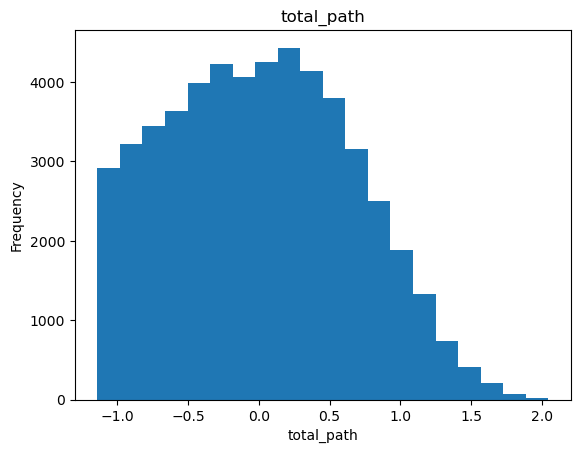

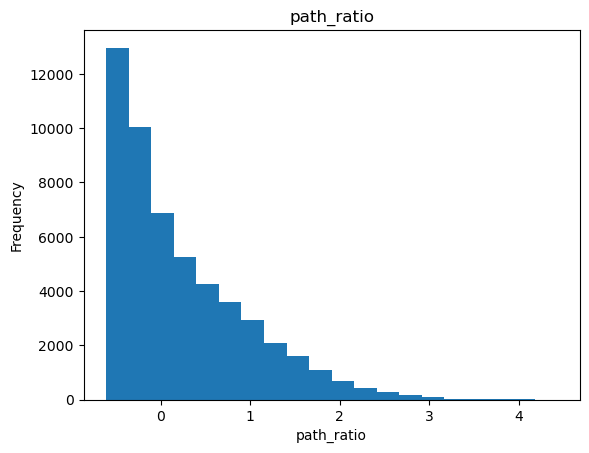

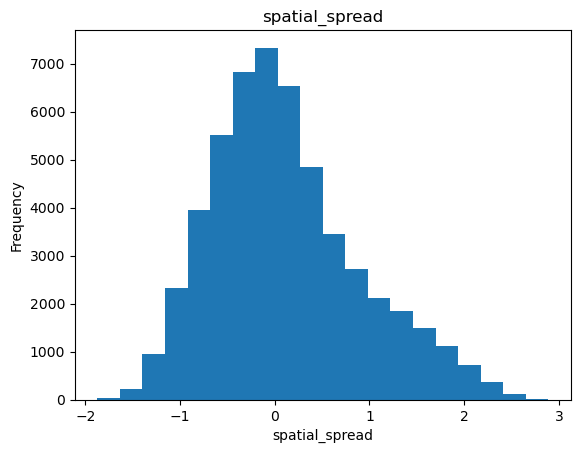

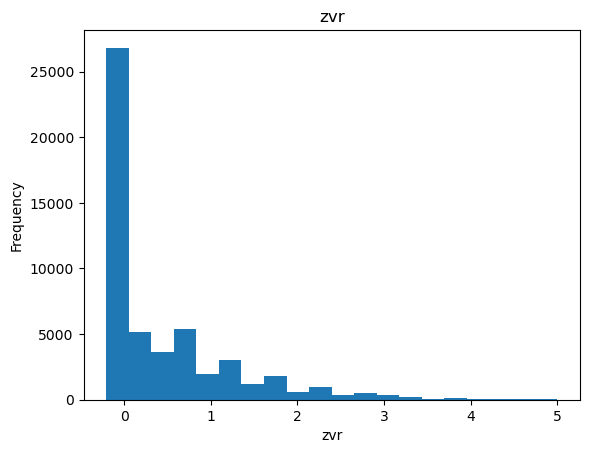

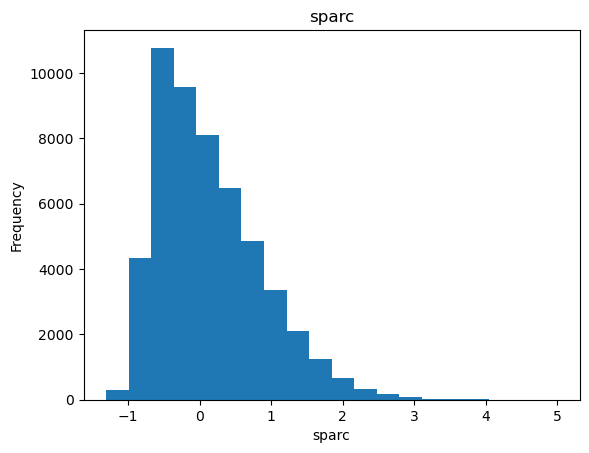

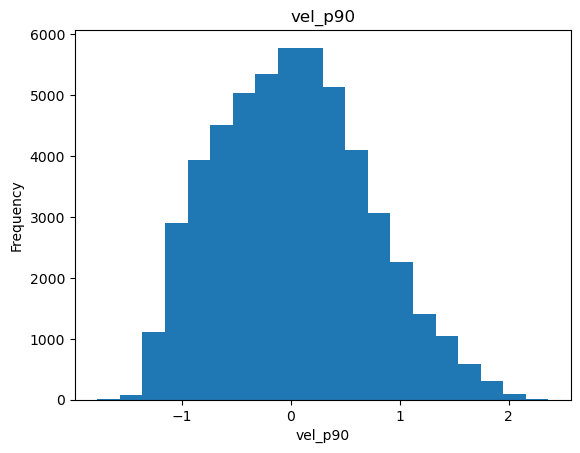

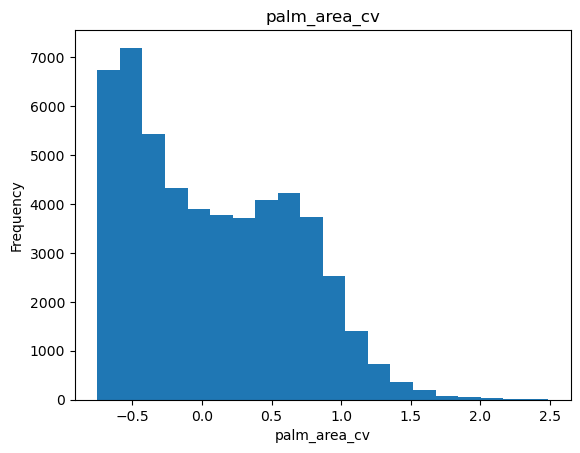

In [234]:
import matplotlib.pyplot as plt

for feat in clustering_features:
    plt.figure()
    pd.DataFrame(X_for_km, columns=clustering_features)[feat].plot(kind='hist', bins=20)
    plt.title(feat)
    plt.xlabel(feat)
    plt.ylabel("Frequency")
    plt.show()

In [15]:
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
from tqdm import tqdm

best_n = 2
best_s = -1
for n in tqdm(range(4, 20, 2)):
    km = MiniBatchKMeans(n_clusters=n, random_state=42, n_init=5).fit(X_for_km)
    s = silhouette_score(X_for_km, km.labels_)
    if s > best_s:
        best_s = s
        best_n = n
        print('best n clusters:', best_n)
n_meta_clusters = best_n

 12%|█▎        | 1/8 [00:29<03:24, 29.24s/it]

best n clusters: 4


100%|██████████| 8/8 [03:45<00:00, 28.23s/it]


In [16]:
# to move elsewhere later as function
from sklearn.cluster import MiniBatchKMeans

N_CLUSTERS = 18
RANDOM_STATE = 42
N_INIT = 5
METHOD = 'log'
skew_targets = [c for c in clustering_features if any(x == c for x in ['total_path', 'path_ratio', 'path_ratio', 'spatial_spread', 'zvr', 'sparc', 'vel_p90', 'palm_area_cv'])]


kmeans = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=N_INIT)
kmeans.fit(X_for_km)

bow_features = []

for vid, group in df.groupby('video_id'):
    
    X = group[clustering_features].copy()
    # 1. Apply Primary Transform
    if METHOD == 'log':
        for col in skew_targets:
            X[col] = np.log1p(X[col])
    elif METHOD == 'sqrt':
        for col in skew_targets:
            X[col] = np.sqrt(np.abs(X[col]))
    elif METHOD == 'quantile':
        # output_distribution='normal' makes it easier for K-means to find spherical blobs
        qt = QuantileTransformer(output_distribution='normal', n_quantiles=100, random_state=42)
        X[skew_targets] = qt.fit_transform(X[skew_targets])
    elif METHOD == 'yeo-johnson':
        pt = PowerTransformer(method='yeo-johnson')
        X[skew_targets] = pt.fit_transform(X[skew_targets])

    X_vid =  scaler.transform(X)
    X_vid = np.clip(X_vid, -clip, clip)
    cluster_labels = kmeans.predict(X_vid)
    
    # Build histogram
    hist, _ = np.histogram(cluster_labels, bins=np.arange(N_CLUSTERS + 1))
    hist = hist / np.sum(hist)  # Normalize to get proportions
    
    bow_features.append((vid, hist))

col_names = [f'BoW_{i}' for i in range(N_CLUSTERS)]
bow_df = pd.DataFrame([x[1] for x in bow_features], columns=col_names)  
bow_df['video_id'] = [x[0] for x in bow_features]   

bow_df[[col for col in bow_df.columns if col != 'video_id']].describe()

,BoW_0,BoW_1,BoW_2,BoW_3,BoW_4,BoW_5,BoW_6,BoW_7,BoW_8,BoW_9,BoW_10,BoW_11,BoW_12,BoW_13,BoW_14,BoW_15,BoW_16,BoW_17
count,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000
mean,0.066170,0.091617,0.087135,0.065921,0.041375,0.045644,0.029790,0.039969,0.051145,0.077856,0.050043,0.066755,0.029610,0.034953,0.045823,0.061918,0.062905,0.051369
std,0.043446,0.030907,0.019256,0.024334,0.015614,0.023405,0.011385,0.017118,0.023519,0.026119,0.018442,0.018954,0.016320,0.029214,0.029574,0.020642,0.023978,0.029250
min,0.002160,0.024283,0.051867,0.027363,0.006070,0.004963,0.011792,0.012669,0.012411,0.030879,0.010899,0.027248,0.007444,0.001122,0.005181,0.027950,0.018041,0.009501
25%,0.036887,0.064479,0.074031,0.047795,0.032350,0.031726,0.021429,0.026688,0.035390,0.055333,0.037043,0.052512,0.018124,0.016165,0.020658,0.047319,0.044148,0.029244
50%,0.054825,0.092453,0.085420,0.062215,0.039764,0.040000,0.029412,0.037736,0.047913,0.079727,0.046924,0.066752,0.024715,0.024096,0.040161,0.061625,0.064732,0.042705
75%,0.089363,0.116982,0.096963,0.079771,0.050922,0.056638,0.036229,0.051710,0.062152,0.094027,0.062905,0.078168,0.038184,0.049086,0.066586,0.074423,0.077054,0.063373
max,0.235205,0.147899,0.154625,0.130435,0.079019,0.168394,0.075000,0.091211,0.133956,0.149770,0.097130,0.125000,0.084668,0.146907,0.135965,0.134396,0.127329,0.136069


In [17]:
from scipy.stats import pearsonr, spearmanr

candidate_features = [col for col in bow_df.columns if col not in ['video_id']]
scores = list(grs_scores.values())

#shuffle scores
import random
#random.seed(42)
#random.shuffle(scores)

feature_df = bow_df[candidate_features]
# compute correlation with scores both pearson and spearman
from scipy.stats import pearsonr, spearmanr
features = list(feature_df.columns)
pearson_corrs = []
spearman_corrs = []
for i in range(feature_df.shape[1]):
    pearson_corr, _ = pearsonr(feature_df.iloc[:, i], scores)
    spearman_corr, _ = spearmanr(feature_df.iloc[:, i], scores)
    pearson_corrs.append(pearson_corr)
    spearman_corrs.append(spearman_corr)

print("Top 10 features by Pearson correlation:")
top_pearson_indices = np.argsort(np.abs(pearson_corrs))[::-1][:12]
for idx in top_pearson_indices:
    print(f"{features[idx]}:        Pearson r = {pearson_corrs[idx]:.4f}, Spearman rho = {spearman_corrs[idx]:.4f}")

Top 10 features by Pearson correlation:
BoW_17:        Pearson r = 0.5819, Spearman rho = 0.5859
BoW_3:        Pearson r = -0.5678, Spearman rho = -0.5573
BoW_2:        Pearson r = -0.4844, Spearman rho = -0.4772
BoW_6:        Pearson r = -0.3933, Spearman rho = -0.4010
BoW_8:        Pearson r = 0.3285, Spearman rho = 0.2498
BoW_15:        Pearson r = 0.3284, Spearman rho = 0.2749
BoW_14:        Pearson r = 0.3109, Spearman rho = 0.3282
BoW_16:        Pearson r = -0.2915, Spearman rho = -0.2519
BoW_1:        Pearson r = -0.2747, Spearman rho = -0.2641
BoW_12:        Pearson r = 0.2663, Spearman rho = 0.3045
BoW_9:        Pearson r = -0.2283, Spearman rho = -0.2275
BoW_13:        Pearson r = 0.2201, Spearman rho = 0.1671


In [18]:
# check cluster centroids for top positive and negative predictors
top_2_positive = np.argsort(pearson_corrs)[-5:]
top_2_negative = np.argsort(pearson_corrs)[:5]
centroids = kmeans.cluster_centers_
feature_names = clustering_features

print("--- Negative Predictors (Novice Moves) ---")
for idx in top_2_negative:
    print(f"Cluster {idx}, (corr: {round(pearson_corrs[idx], 3)}): {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

print("\n--- Positive Predictors (Expert Moves) ---")
for idx in reversed(top_2_positive):
    print(f"Cluster {idx}, (corr: {round(pearson_corrs[idx], 3)}): {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

--- Negative Predictors (Novice Moves) ---
Cluster 3, (corr: -0.568): {'total_path': np.float64(-0.05), 'path_ratio': np.float64(-0.15), 'spatial_spread': np.float64(0.22), 'sparc': np.float64(0.34), 'palm_area_cv': np.float64(-0.31)}
Cluster 2, (corr: -0.484): {'total_path': np.float64(0.25), 'path_ratio': np.float64(-0.32), 'spatial_spread': np.float64(0.76), 'sparc': np.float64(-0.49), 'palm_area_cv': np.float64(-0.19)}
Cluster 6, (corr: -0.393): {'total_path': np.float64(0.78), 'path_ratio': np.float64(-0.2), 'spatial_spread': np.float64(1.2), 'sparc': np.float64(0.58), 'palm_area_cv': np.float64(0.23)}
Cluster 16, (corr: -0.291): {'total_path': np.float64(-0.74), 'path_ratio': np.float64(-0.09), 'spatial_spread': np.float64(-0.59), 'sparc': np.float64(0.74), 'palm_area_cv': np.float64(-0.46)}
Cluster 1, (corr: -0.275): {'total_path': np.float64(-0.55), 'path_ratio': np.float64(-0.34), 'spatial_spread': np.float64(-0.09), 'sparc': np.float64(-0.48), 'palm_area_cv': np.float64(-0.45

In [20]:
#top_features = ['num_reversals_Right', 'total_duration_Left', 'nmu_peaks_Right', 'total_path_Right', 'ldlj_smoothness_Left', 'total_angular_path_Right']

top_features = [
    'angular_dir_switches_Right',
    'nmu_peaks_Right',
    'total_duration_Left',
    #'total_duration_Right',
    'total_path_Right',
    'angular_dir_switches_Left',
    'nmu_peaks_Left',
    'ldlj_smoothness_Left',
    'total_path_Left',
    'total_angular_path_Right',
    'ldlj_smoothness_Right',
    'total_angular_path_Left'
    ]

top_features_right = [feat for feat in top_features if 'Right' in feat]

# load top feature df and combine with aggregated window features
comb_df = pd.merge(df_pc1_features, bow_df, left_index=True, right_index=True)

#candidate_features = [c for c in candidate_features if c not in ['palm_area_cv_p10', 'palm_area_cv_p90', 'palm_area_cv_mean', 'palm_area_cv_std', 'is_idle_p90', 'is_idle_std', 'is_idle_median', 'is_idle_p10']]
df_res_leakage_free = leakage_free_residual_analysis(comb_df, top_features_right, candidate_features, base_features=['velocity_corr'], top_n=1, perform_shuffle=False)
df_res_leakage_free

Analyzing Folds: 100%|██████████| 28/28 [00:02<00:00, 11.51it/s]


,Feature,Partial_R2_mean,Partial_R2_std,Partial_R2_min,Resid_Corr_mean,Selection_Stability
11,BoW_3,0.195777,0.015216,1.647883e-01,-0.406203,0.607143
9,BoW_17,0.191792,0.018614,1.554406e-01,0.396222,0.321429
7,BoW_15,0.171064,0.017160,1.386840e-01,0.402833,0.071429
16,BoW_8,0.107151,0.011814,8.147045e-02,0.319087,0.000000
14,BoW_6,0.093083,0.011716,7.216460e-02,-0.289381,0.000000
10,BoW_2,0.081412,0.011750,6.398045e-02,-0.259377,0.000000
3,BoW_11,0.041948,0.009569,2.380196e-02,-0.197464,0.000000
15,BoW_7,0.031087,0.008108,1.648398e-02,-0.160851,0.000000
8,BoW_16,0.029641,0.005609,1.936181e-02,-0.162424,0.000000
4,BoW_12,0.007307,0.005534,2.886402e-03,0.078742,0.000000


In [36]:
from src_final.models.mlp_regressor import PyTorchMLPEnsemble
from src_final.models.baseline_loso import evaluate_loso_mlp_ensemble, run_nested_loso

df_nested_results = run_nested_loso(
    df=comb_df,
    primary_features=top_features_right,
    candidate_features=candidate_features,
    extra_features=['velocity_corr'],
    model_type='mlp',
    model_params={'hidden_dim': 16, 'n_hidden': 1, 'n_models': 3, 'dropout': 0.15, 'batch_size': 16},
    top_n=10,
    print_fold_metrics=True,
    corr_threshold=0.7,
    pr2_threshold=0.05
)

Surgeon 1 | Train MAE: 3.4545 | Test MAE: 4.1489 | Selected Features: ['BoW_3', 'BoW_15', 'BoW_17', 'BoW_8', 'BoW_2', 'BoW_6'] | Selected PR2s: [np.float64(0.1837), np.float64(0.1636), np.float64(0.1554), np.float64(0.0847), np.float64(0.0729), np.float64(0.0722)]
Surgeon 2 | Train MAE: 3.5078 | Test MAE: 3.0542 | Selected Features: ['BoW_3', 'BoW_17', 'BoW_15', 'BoW_8', 'BoW_2', 'BoW_6'] | Selected PR2s: [np.float64(0.2206), np.float64(0.1937), np.float64(0.1589), np.float64(0.1161), np.float64(0.0927), np.float64(0.0864)]
Surgeon 3 | Train MAE: 3.2114 | Test MAE: 10.4826 | Selected Features: ['BoW_17', 'BoW_15', 'BoW_3', 'BoW_8', 'BoW_6', 'BoW_2'] | Selected PR2s: [np.float64(0.2489), np.float64(0.2144), np.float64(0.2112), np.float64(0.1094), np.float64(0.099), np.float64(0.0824)]
Surgeon 4 | Train MAE: 3.3846 | Test MAE: 3.6162 | Selected Features: ['BoW_3', 'BoW_17', 'BoW_15', 'BoW_8', 'BoW_6', 'BoW_2'] | Selected PR2s: [np.float64(0.1776), np.float64(0.1704), np.float64(0.1662), 

**Try Lasso or Elasticnet**

LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 52.79it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7584 | MAE: 4.7264 | MAE STD: 3.7999 | R2: 0.5755 | Adj R2: 0.4561

Feature Weights:
   Feature  Average_Weight  Std_Weight
0     bias       49.938586    0.302804
1      PC1       -2.317636    0.087643
2    BoW_0        1.321500    0.235634
3    BoW_1       -0.003817    0.019833
4    BoW_2       -0.596902    0.200036
5    BoW_3        0.222235    0.143527
6    BoW_4        0.000000    0.000000
7    BoW_5       -1.846432    0.199068
8    BoW_6        0.000000    0.000000
9    BoW_7       -0.028311    0.121857
10   BoW_8        0.000000    0.000000
11   BoW_9        0.000000    0.000000
12  BoW_10        0.000000    0.000000
13  BoW_11       -1.309569    0.131416
14  BoW_12        0.033201    0.061188
15  BoW_13       -0.107761    0.124555
16  BoW_14        0.000000    0.000000
17  BoW_15        0.000000    0.000000

--- Per-Fold Performance Summary ---
    Train_MAE   Test_MAE  Test_Corr
1    4.222288   3.783604   0.984900
2    4.183936   3.

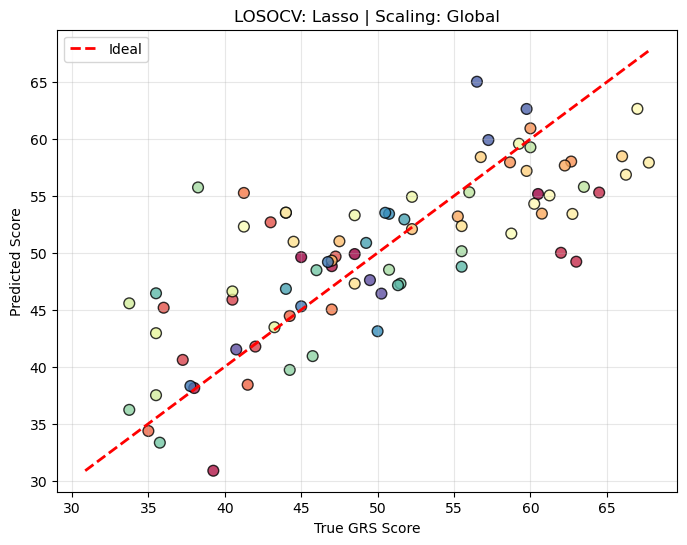

In [31]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV, Lasso

_, _, _ = evaluate_loso_model(comb_df, top_features_right, model_class=Lasso, model_params={'alpha': 0.5},extra_features=candidate_features, print_fold_metrics=True, pca_components=[0])

### Significance Test 

In [ ]:
all_shuffled_r2 = []
all_shuffled_top_BoW = []

seeds = random.sample(range(0, 100), 25)
for seed in seeds:
    df_res = leakage_free_residual_analysis(comb_df, top_features, candidate_features, base_features=['velocity_corr'], top_n=2, perform_shuffle=True, seed=seed)
    top_3_r2 = df_res['Shuffled_R2_mean'].values[:3]
    bow_6_r2 = df_res[df_res['Feature']=='BoW_7']['Shuffled_R2_mean'].values[0]
    all_shuffled_top_BoW.append(bow_6_r2)
    print(f"Seed {seed}: Top 3 R2: {top_3_r2}")
    for r2 in top_3_r2:
        all_shuffled_r2.append(r2)

Analyzing Folds: 100%|██████████| 28/28 [00:04<00:00,  5.87it/s]


Seed 12: Top 3 R2: [0.04406501 0.04169252 0.03497045]


Analyzing Folds: 100%|██████████| 28/28 [00:05<00:00,  4.85it/s]


Seed 47: Top 3 R2: [0.03420142 0.02730518 0.0225491 ]


Analyzing Folds: 100%|██████████| 28/28 [00:04<00:00,  5.71it/s]


...

Seed 62: Top 3 R2: [0.10098647 0.09899331 0.09154715]


Analyzing Folds: 100%|██████████| 28/28 [00:04<00:00,  6.53it/s]


Seed 61: Top 3 R2: [0.04841938 0.04676928 0.04644585]


Analyzing Folds: 100%|██████████| 28/28 [00:03<00:00,  7.34it/s]

Seed 36: Top 3 R2: [0.15946643 0.14011028 0.13101303]


Empirical p-value: 0.200
Z-score vs Null: 0.71


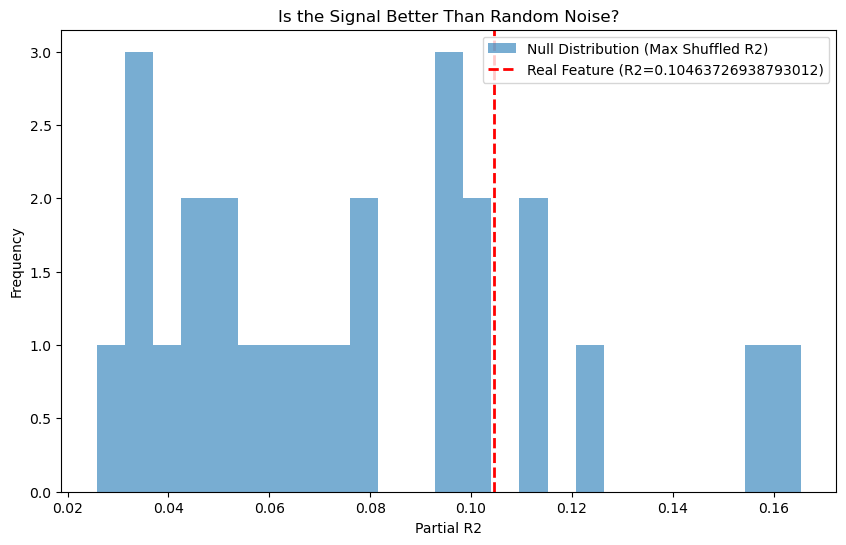

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- DATA INPUT ---
# Your top real feature R2
real_top_r2 = 0.10463726938793012

# Replace this with your actual list of 50 'Max' Shuffled R2 values 
# (The highest R2 observed in each of the 50 shuffle runs)

shuffled_max_r2s = all_shuffled_r2[::3] # your 50 max values

def evaluate_significance(real_val, null_distribution):
    null_distribution = np.array(null_distribution)
    
    # Empirical p-value: what fraction of the null is >= our real signal?
    p_value = np.mean(null_distribution >= real_val)
    
    # Z-score: how many standard deviations is the real signal from the null mean?
    z_score = (real_val - np.mean(null_distribution)) / np.std(null_distribution)
    
    return p_value, z_score

p_val, z_score = evaluate_significance(real_top_r2, shuffled_max_r2s)

print(f"Empirical p-value: {p_val:.3f}")
print(f"Z-score vs Null: {z_score:.2f}")

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.hist(shuffled_max_r2s, bins=25, alpha=0.6, label='Null Distribution (Max Shuffled R2)')
plt.axvline(real_top_r2, color='red', linestyle='--', linewidth=2, label=f'Real Feature (R2={real_top_r2})')
plt.title("Is the Signal Better Than Random Noise?")
plt.xlabel("Partial R2")
plt.ylabel("Frequency")
plt.legend()
plt.show()

**Does this confirm the need for MIL?**

Yes. univariate analysis has effectively "cleared the field." have proven that:

Individual local patterns (BoW bins) are just echoes of global efficiency.

The "Style" or "Technique" signal is not contained in the frequency of common movements.

This is the perfect lead-in for your Gated Attention MIL. The MIL head doesn't care about the frequency of "Fast" windows. It looks for co-occurrences and non-linear transitions. It might find that "Jerk" only matters when "Palm Area CV" is also high. That kind of interaction is something a univariate Partial R 
R2 test on a BoW bin will never see.

## **TO DO**
- Need To Make a Statistical Test
    to see if this approach is statistically significant to extract features.  
    i.e how probable is it that we get this high partial R2 in random scenario?

    - spatial spread is statistically strong enough in the shuffle test
    - palm_area_cv not, but with the correlation argument with skill scores maybe

    => solution that is easier to defend is probably to select features within folds directly.

- Just observed that spatial spread p80 (idle thresh < 15px and, log transform, and 1.5 sec window) is very strong.

- Do feature selection directly within LOSO loop, so leakage argument doesn't hold, with various features selection methods

- Do a hyperparameter search 